In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

/tmp/ipykernel_44/3223033590.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

hoda = HODA(
        rank=5,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        delta=None,
       


)
hoda.fit(X,y)

Backward HODA model rank=(5, 5):  22%|██▏       | 14/64 [00:03<00:11,  4.35it/s]


HODA(extra_train_info=True, init='random', max_iter=64, obj='tr',
     random_state=42, rank=5, verbose=True)

In [6]:
hoda.train_info_

{'backward': {'iteration': [1,
   1,
   2,
   2,
   3,
   3,
   4,
   4,
   5,
   5,
   6,
   6,
   7,
   7,
   8,
   8,
   9,
   9,
   10,
   10,
   11,
   11,
   12,
   12,
   13,
   13,
   14,
   14,
   15,
   15],
  'mode': [0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1],
  'update': [1.2144730053576542,
   1.5786752900680958,
   1.2775379799292805,
   1.201986914363967,
   0.2347679257278195,
   0.13535846309864197,
   0.040515759328606536,
   0.01743879945105687,
   0.01006628996931482,
   0.003709331309156075,
   0.0022555847616173136,
   0.0008369954778887151,
   0.0005071190844089916,
   0.00019119919771742408,
   0.00011503080023500311,
   4.385700522235468e-05,
   2.6266341894320007e-05,
   1.007624912296466e-05,
   6.020067435251078e-06,
   2.3164580573383558e-06,
   1.3822700905719817e-06,
   5.326416240736597e-07,
   3.1764463984685213e-07,
   

<Axes: xlabel='iteration', ylabel='log_loss'>

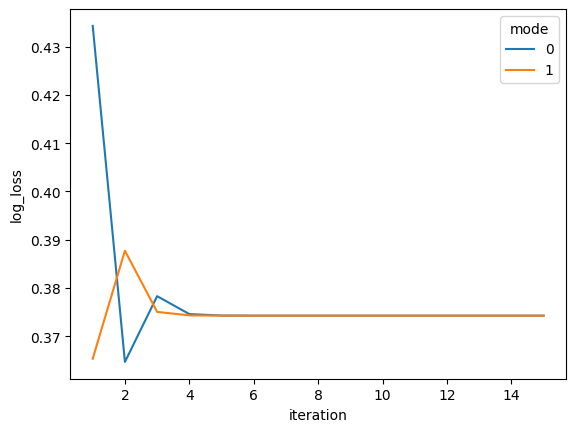

In [8]:
import seaborn as sns
sns.lineplot(data=hoda.train_info_['backward'], x='iteration', y='log_loss', hue='mode')

<Axes: xlabel='iteration', ylabel='F_tr'>

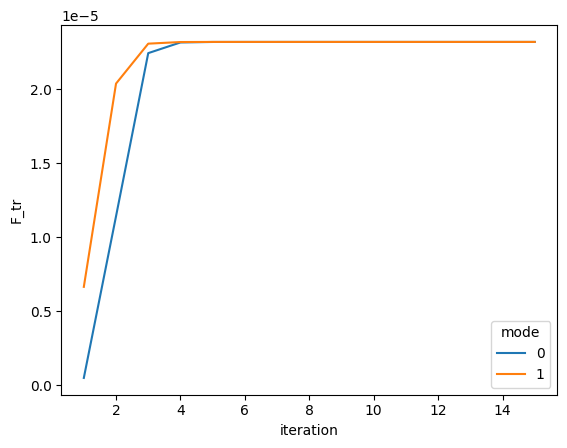

In [9]:
sns.lineplot(data=hoda.train_info_['backward'], x='iteration', y='F_tr', hue='mode')